# SKCM Somatic MAF Analysis

## Project Overview

This notebook analyzes open-access somatic mutation data from TCGA-SKCM, the TCGA skin cutaneous melanoma cohort. The goal is to practice clinically oriented cancer genomics analysis using Mutation Annotation Format (MAF) data.

SKCM was selected because melanoma is highly relevant to immunotherapy, tumor mutational burden, immune escape, and molecular oncology biomarker development.

This project is for educational and portfolio purposes only. It is not intended for diagnosis, treatment decisions, or clinical reporting.

## Planned Workflow

1. Import Python packages.
2. Load open-access TCGA-SKCM MAF data.
3. Inspect the dataset structure.
4. Summarize the number of variants and tumor samples.
5. Summarize mutation classifications and variant types.
6. Identify frequently mutated genes.
7. Calculate mutation counts per sample as a simple tumor mutation burden-style proxy.
8. Flag selected melanoma- and immunotherapy-relevant genes.
9. Export summary tables and figures.
10. Document interpretation and limitations.

In [1]:
# Core packages
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

In [2]:
# Define project paths
project_dir = Path("..")
data_dir = project_dir / "data"
results_dir = project_dir / "results" / "skcm"

# Create results directory if it does not already exist
results_dir.mkdir(parents=True, exist_ok=True)

data_dir, results_dir

(WindowsPath('../data'), WindowsPath('../results/skcm'))

## Data Source

This project will use open-access TCGA-SKCM somatic mutation data from the NCI Genomic Data Commons (GDC).

The GDC describes MAF files as tab-delimited project-level files containing aggregated mutation information from VCF files. GDC somatic MAF files, also called Masked Somatic Mutation files, are open-access files that have been processed to remove lower-quality and potential germline variants.

Raw or large data files are not stored directly in this GitHub repository. Download instructions are documented in the project `data/README.md`.

In [3]:
# Directory containing downloaded SKCM MAF files
skcm_maf_dir = data_dir / "skcm_maf"

# Find all compressed MAF files
skcm_maf_files = sorted(skcm_maf_dir.rglob("*.maf.gz"))

print(f"Found {len(skcm_maf_files)} SKCM MAF files.")

Found 150 SKCM MAF files.


In [4]:
if len(skcm_maf_files) > 0:
    maf_list = []

    for file in skcm_maf_files:
        temp_maf = pd.read_csv(file, sep="\t", comment="#", low_memory=False)
        temp_maf["source_file"] = file.name
        maf_list.append(temp_maf)

    skcm_maf = pd.concat(maf_list, ignore_index=True)

    print(f"Loaded combined SKCM MAF with {skcm_maf.shape[0]:,} rows and {skcm_maf.shape[1]:,} columns.")
else:
    skcm_maf = None
    print(f"No MAF files found in: {skcm_maf_dir}")

Loaded combined SKCM MAF with 85,981 rows and 141 columns.


In [5]:
skcm_maf.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,dbSNP_RS,dbSNP_Val_Status,Tumor_Sample_Barcode,Matched_Norm_Sample_Barcode,Match_Norm_Seq_Allele1,Match_Norm_Seq_Allele2,Tumor_Validation_Allele1,Tumor_Validation_Allele2,Match_Norm_Validation_Allele1,Match_Norm_Validation_Allele2,Verification_Status,Validation_Status,Mutation_Status,Sequencing_Phase,Sequence_Source,Validation_Method,Score,BAM_File,Sequencer,Tumor_Sample_UUID,Matched_Norm_Sample_UUID,HGVSc,HGVSp,HGVSp_Short,Transcript_ID,Exon_Number,t_depth,t_ref_count,t_alt_count,n_depth,n_ref_count,n_alt_count,all_effects,Allele,Gene,Feature,Feature_type,...,gnomAD_ASJ_AF,gnomAD_EAS_AF,gnomAD_FIN_AF,gnomAD_NFE_AF,gnomAD_OTH_AF,gnomAD_SAS_AF,MAX_AF,MAX_AF_POPS,gnomAD_non_cancer_AF,gnomAD_non_cancer_AFR_AF,gnomAD_non_cancer_AMI_AF,gnomAD_non_cancer_AMR_AF,gnomAD_non_cancer_ASJ_AF,gnomAD_non_cancer_EAS_AF,gnomAD_non_cancer_FIN_AF,gnomAD_non_cancer_MID_AF,gnomAD_non_cancer_NFE_AF,gnomAD_non_cancer_OTH_AF,gnomAD_non_cancer_SAS_AF,gnomAD_non_cancer_MAX_AF_adj,gnomAD_non_cancer_MAX_AF_POPS_adj,CLIN_SIG,SOMATIC,PUBMED,TRANSCRIPTION_FACTORS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,miRNA,IMPACT,PICK,VARIANT_CLASS,TSL,HGVS_OFFSET,PHENO,GENE_PHENO,CONTEXT,tumor_bam_uuid,normal_bam_uuid,case_id,GDC_FILTER,COSMIC,hotspot,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers,source_file
0,PER3,8863,BI,GRCh38,chr1,7785510,7785510,+,Silent,SNP,C,C,T,rs375818157,NaN,TCGA-EB-A5SE-01A-11D-A30X-08,TCGA-EB-A5SE-10A-01D-A30X-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,55f628bc-f199-4eb0-9388-9945bf2deabd,5ee0cf3a-5e46-4644-af01-64abd1c26929,c.198C>T,p.Phe66=,p.F66=,ENST00000361923,2/21,59,32,27,53,NaN,NaN,"PER3,synonymous_variant,p.F66=,ENST00000613533...",T,ENSG00000049246,ENST00000361923,Transcript,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000116,EA,0.000027,0.000024,0.0,0.0,0.0,0.0,0.0,0.0,0.000046,0.0,0.0,0.000046,nfe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOW,NaN,SNV,1.0,NaN,NaN,1.0,TACTTCCCCTC,912ba95c-848d-4c12-ac7e-b37a6897cd6f,ed47855f-50a3-445d-9502-7078bbc39618,fda160c9-efdc-4263-98f1-e38b00571b4d,NaN,COSM3492540,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...
1,ATP13A2,23400,BI,GRCh38,chr1,17005064,17005064,+,Silent,SNP,G,G,A,NaN,NaN,TCGA-EB-A5SE-01A-11D-A30X-08,TCGA-EB-A5SE-10A-01D-A30X-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,55f628bc-f199-4eb0-9388-9945bf2deabd,5ee0cf3a-5e46-4644-af01-64abd1c26929,c.297C>T,p.Ser99=,p.S99=,ENST00000326735,4/29,45,21,24,73,NaN,NaN,"ATP13A2,synonymous_variant,p.S99=,ENST00000326...",A,ENSG00000159363,ENST00000326735,Transcript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LOW,1.0,SNV,1.0,NaN,1,1.0,TGCCAGGAACT,912ba95c-848d-4c12-ac7e-b37a6897cd6f,ed47855f-50a3-445d-9502-7078bbc39618,fda160c9-efdc-4263-98f1-e38b00571b4d,NaN,COSM3478465;COSM4904013,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...
2,AKR7A3,22977,BI,GRCh38,chr1,19285108,19285108,+,Missense_Mutation,SNP,A,A,T,NaN,NaN,TCGA-EB-A5SE-01A-11D-A30X-08,TCGA-EB-A5SE-10A-01D-A30X-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Somatic,NaN,NaN,NaN,NaN,NaN,NaN,55f628bc-f199-4eb0-9388-9945bf2deabd,5ee0cf3a-5e46-4644-af01-64abd1c26929,c.514T>A,p.Tyr172Asn,p.Y172N,ENST00000361640,4/7,55,27,27,58,NaN,NaN,"AKR7A3,missense_variant,p.Y172N,ENST0000036164...",T,ENSG00000162482,ENST00000361640,Transcript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,1.0,SNV,1.0,NaN,1,NaN,ATTGTACATGC,912ba95c-848d-4c12-ac7e-b37a6897cd6f,ed47855f-50a3-445d-9502-7078bbc39618,fda160c9-efdc-4263-98f1-e38b00571b4d,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...
3,AKR7A3

In [6]:
skcm_maf.shape

(85981, 141)

In [7]:
skcm_maf.columns.tolist()

['Hugo_Symbol',
 'Entrez_Gene_Id',
 'Center',
 'NCBI_Build',
 'Chromosome',
 'Start_Position',
 'End_Position',
 'Strand',
 'Variant_Classification',
 'Variant_Type',
 'Reference_Allele',
 'Tumor_Seq_Allele1',
 'Tumor_Seq_Allele2',
 'dbSNP_RS',
 'dbSNP_Val_Status',
 'Tumor_Sample_Barcode',
 'Matched_Norm_Sample_Barcode',
 'Match_Norm_Seq_Allele1',
 'Match_Norm_Seq_Allele2',
 'Tumor_Validation_Allele1',
 'Tumor_Validation_Allele2',
 'Match_Norm_Validation_Allele1',
 'Match_Norm_Validation_Allele2',
 'Verification_Status',
 'Validation_Status',
 'Mutation_Status',
 'Sequencing_Phase',
 'Sequence_Source',
 'Validation_Method',
 'Score',
 'BAM_File',
 'Sequencer',
 'Tumor_Sample_UUID',
 'Matched_Norm_Sample_UUID',
 'HGVSc',
 'HGVSp',
 'HGVSp_Short',
 'Transcript_ID',
 'Exon_Number',
 't_depth',
 't_ref_count',
 't_alt_count',
 'n_depth',
 'n_ref_count',
 'n_alt_count',
 'all_effects',
 'Allele',
 'Gene',
 'Feature',
 'Feature_type',
 'One_Consequence',
 'Consequence',
 'cDNA_position',
 'C

In [8]:
n_variants = skcm_maf.shape[0]
n_samples = skcm_maf["Tumor_Sample_Barcode"].nunique()
n_genes = skcm_maf["Hugo_Symbol"].nunique()

print(f"Number of variants: {n_variants:,}")
print(f"Number of tumor samples: {n_samples:,}")
print(f"Number of mutated genes: {n_genes:,}")

Number of variants: 85,981
Number of tumor samples: 150
Number of mutated genes: 15,176


In [9]:
mutation_class_counts = (
    skcm_maf["Variant_Classification"]
    .value_counts()
    .reset_index()
)

mutation_class_counts.columns = ["Variant_Classification", "Count"]
mutation_class_counts

,Variant_Classification,Count
0,Missense_Mutation,50901
1,Silent,27899
2,Nonsense_Mutation,3154
3,Intron,833
4,Splice_Site,710
5,Splice_Region,698
6,RNA,638
7,Frame_Shift_Del,292
8,3'UTR,205
9,5'Flank,129


In [10]:
variant_type_counts = (
    skcm_maf["Variant_Type"]
    .value_counts()
    .reset_index()
)

variant_type_counts.columns = ["Variant_Type", "Count"]
variant_type_counts

,Variant_Type,Count
0,SNP,85470
1,DEL,388
2,INS,119
3,ONP,2
4,TNP,2


In [11]:
top_mutated_genes = (
    skcm_maf["Hugo_Symbol"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_mutated_genes.columns = ["Gene", "Mutation_Count"]
top_mutated_genes

,Gene,Mutation_Count
0,TTN,701
1,MUC16,454
2,DNAH5,196
3,PCLO,164
4,LRP1B,119
5,DNAH7,105
6,DNAH9,104
7,ANK3,103
8,FAT4,102
9,MGAM,102


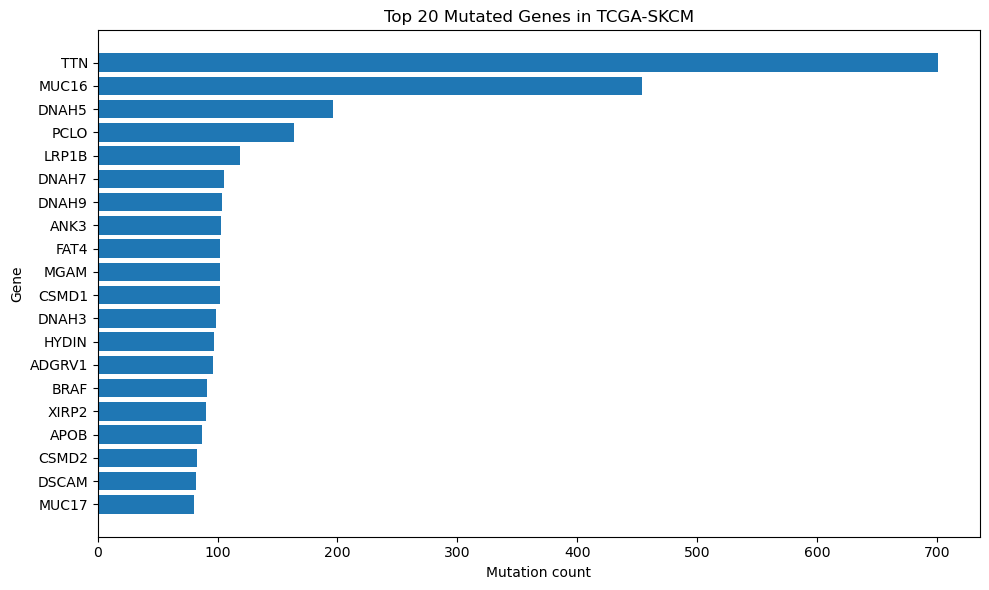

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(top_mutated_genes["Gene"], top_mutated_genes["Mutation_Count"])
plt.gca().invert_yaxis()
plt.xlabel("Mutation count")
plt.ylabel("Gene")
plt.title("Top 20 Mutated Genes in TCGA-SKCM")
plt.tight_layout()
plt.show()

In [13]:
mutation_counts_per_sample = (
    skcm_maf
    .groupby("Tumor_Sample_Barcode")
    .size()
    .reset_index(name="Mutation_Count")
    .sort_values("Mutation_Count", ascending=False)
)

mutation_counts_per_sample.head(20)

,Tumor_Sample_Barcode,Mutation_Count
113,TCGA-FR-A726-01A-11D-A32N-08,8473
130,TCGA-GN-A266-06A-11D-A197-08,4657
149,TCGA-Z2-A8RT-06A-11D-A372-08,3507
94,TCGA-EE-A3J5-06A-11D-A20D-08,2584
87,TCGA-EE-A20C-06A-11D-A196-08,2516
148,TCGA-YG-AA3N-01A-11D-A38G-08,2442
47,TCGA-EB-A41A-01A-11D-A24R-08,2253
52,TCGA-EB-A431-01A-11D-A25O-08,2086
133,TCGA-GN-A26C-01A-11D-A19A-08,2060
23,TCGA-D3-A5GO-06A-12D-A27K-08,1889


In [14]:
mutation_counts_per_sample["Mutation_Count"].describe()

count     150.000000
mean      573.206667
std       941.645128
min         6.000000
25%       101.000000
50%       325.000000
75%       605.500000
max      8473.000000
Name: Mutation_Count, dtype: float64

In [15]:
skcm_genes_of_interest = [
    "BRAF", "NRAS", "NF1", "KIT", "PTEN", "TP53", "CDKN2A",
    "B2M", "JAK1", "JAK2", "HLA-A", "HLA-B", "HLA-C"
]

skcm_gene_subset = skcm_maf[
    skcm_maf["Hugo_Symbol"].isin(skcm_genes_of_interest)
].copy()

skcm_gene_summary = (
    skcm_gene_subset
    .groupby("Hugo_Symbol")
    .size()
    .reset_index(name="Mutation_Count")
    .sort_values("Mutation_Count", ascending=False)
)

skcm_gene_summary

,Hugo_Symbol,Mutation_Count
1,BRAF,91
8,NF1,32
9,NRAS,31
11,TP53,22
2,CDKN2A,14
10,PTEN,13
7,KIT,7
5,JAK1,5
6,JAK2,4
0,B2M,2


In [16]:
mutation_class_counts.to_csv(results_dir / "skcm_mutation_classification_counts.csv", index=False)
variant_type_counts.to_csv(results_dir / "skcm_variant_type_counts.csv", index=False)
top_mutated_genes.to_csv(results_dir / "skcm_top_mutated_genes.csv", index=False)
mutation_counts_per_sample.to_csv(results_dir / "skcm_mutation_counts_per_sample.csv", index=False)
skcm_gene_summary.to_csv(results_dir / "skcm_genes_of_interest_summary.csv", index=False)

## Initial Interpretation

The combined TCGA-SKCM MAF dataset contained 85,981 somatic mutation records across the downloaded aliquot-level MAF files. Initial summaries focused on mutation classifications, variant types, recurrently altered genes, and per-sample mutation counts.

Melanoma is expected to show a relatively high mutational burden compared with many other cancer types, often reflecting ultraviolet-associated mutagenesis. In this educational analysis, mutation counts per sample are used as a simplified TMB-style proxy rather than a clinically validated TMB calculation.

## Limitations

This analysis uses open-access masked somatic mutation MAF files from GDC. The workflow is intended for educational portfolio development and does not represent a validated clinical pipeline. Mutation counts per sample are not equivalent to clinically reportable TMB because they are not normalized to a validated callable territory, assay footprint, or laboratory-specific reporting framework.

## Hypermutated / Outlier Sample Summary

Mutation counts per sample were calculated as a simplified tumor mutational burden-style proxy. This is not equivalent to clinically validated TMB because it is not normalized to a validated assay footprint, callable territory, or laboratory-specific reporting framework.

However, identifying samples with unusually high mutation counts is useful for exploratory analysis because melanoma is often associated with high somatic mutation burden, and hypermutated tumors may be relevant to immunotherapy-related biomarker concepts.

In [17]:
# Calculate mutation count summary statistics
mutation_count_summary = mutation_counts_per_sample["Mutation_Count"].describe()
mutation_count_summary

count     150.000000
mean      573.206667
std       941.645128
min         6.000000
25%       101.000000
50%       325.000000
75%       605.500000
max      8473.000000
Name: Mutation_Count, dtype: float64

In [18]:
# Define outlier threshold using the IQR method
q1 = mutation_counts_per_sample["Mutation_Count"].quantile(0.25)
q3 = mutation_counts_per_sample["Mutation_Count"].quantile(0.75)
iqr = q3 - q1

outlier_threshold = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Outlier threshold: {outlier_threshold:.2f} mutations")

Q1: 101.00
Q3: 605.50
IQR: 504.50
Outlier threshold: 1362.25 mutations


In [19]:
hypermutated_samples = (
    mutation_counts_per_sample[
        mutation_counts_per_sample["Mutation_Count"] > outlier_threshold
    ]
    .copy()
    .sort_values("Mutation_Count", ascending=False)
)

print(f"Number of outlier/hypermutated samples: {hypermutated_samples.shape[0]:,}")

hypermutated_samples.head(20)

Number of outlier/hypermutated samples: 14


,Tumor_Sample_Barcode,Mutation_Count
113,TCGA-FR-A726-01A-11D-A32N-08,8473
130,TCGA-GN-A266-06A-11D-A197-08,4657
149,TCGA-Z2-A8RT-06A-11D-A372-08,3507
94,TCGA-EE-A3J5-06A-11D-A20D-08,2584
87,TCGA-EE-A20C-06A-11D-A196-08,2516
148,TCGA-YG-AA3N-01A-11D-A38G-08,2442
47,TCGA-EB-A41A-01A-11D-A24R-08,2253
52,TCGA-EB-A431-01A-11D-A25O-08,2086
133,TCGA-GN-A26C-01A-11D-A19A-08,2060
23,TCGA-D3-A5GO-06A-12D-A27K-08,1889


In [20]:
hypermutated_samples.to_csv(
    results_dir / "skcm_hypermutated_outlier_samples.csv",
    index=False
)

## Melanoma and Immunotherapy-Relevant Genes of Interest

A focused subset of genes was selected to highlight variants in genes relevant to melanoma biology, MAPK pathway activation, tumor suppressor loss, antigen presentation, and interferon signaling.

Genes included:

- `BRAF`, `NRAS`, `NF1`, and `KIT` for melanoma-associated oncogenic signaling
- `TP53`, `PTEN`, and `CDKN2A` for tumor suppressor biology
- `B2M`, `JAK1`, and `JAK2` for immune escape and interferon-response relevance

This table is intended for exploratory portfolio analysis only and does not represent clinical variant interpretation.

In [21]:
skcm_genes_of_interest = [
    "BRAF", "NRAS", "NF1", "KIT",
    "TP53", "PTEN", "CDKN2A",
    "B2M", "JAK1", "JAK2"
]

# Select columns that are useful for a portfolio-level variant table
goi_columns = [
    "Hugo_Symbol",
    "Chromosome",
    "Start_Position",
    "End_Position",
    "Reference_Allele",
    "Tumor_Seq_Allele2",
    "Variant_Classification",
    "Variant_Type",
    "Tumor_Sample_Barcode",
    "HGVSc",
    "HGVSp_Short",
    "Protein_position",
    "t_depth",
    "t_ref_count",
    "t_alt_count",
    "source_file"
]

# Keep only columns that are actually present in the MAF
available_goi_columns = [col for col in goi_columns if col in skcm_maf.columns]

skcm_goi_variants = (
    skcm_maf[
        skcm_maf["Hugo_Symbol"].isin(skcm_genes_of_interest)
    ][available_goi_columns]
    .copy()
)

skcm_goi_variants.head(20)

,Hugo_Symbol,Chromosome,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Variant_Classification,Variant_Type,Tumor_Sample_Barcode,HGVSc,HGVSp_Short,Protein_position,t_depth,t_ref_count,t_alt_count,source_file
138,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-EB-A5SE-01A-11D-A30X-08,c.1919T>A,p.V640E,640/806,163,41,121,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...
546,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-EB-A6R0-01A-12D-A32N-08,c.1919T>A,p.V640E,640/806,147,71,76,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...
547,BRAF,chr7,140753337,140753337,C,T,Missense_Mutation,SNP,TCGA-EB-A6R0-01A-12D-A32N-08,c.1918G>A,p.V640M,640/806,148,72,76,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...
594,PTEN,chr10,87957916,87957917,-,AC,Frame_Shift_Ins,INS,TCGA-EB-A6R0-01A-12D-A32N-08,c.699_700dup,p.R234Hfs*23,233/403,116,59,57,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...
2401,JAK2,chr9,5054784,5054784,C,T,Missense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.836C>T,p.P279L,279/1132,57,18,39,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...
2413,CDKN2A,chr9,21971187,21971187,G,A,Nonsense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.172C>T,p.R58*,58/156,13,5,8,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...
3320,TP53,chr17,7674886,7674886,A,C,Missense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.645T>G,p.S215R,215/393,55,34,20,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...
3321,TP53,chr17,7674894,7674894,G,A,Nonsense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.637C>T,p.R213*,213/393,58,40,18,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...
4525,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-ER-A19K-01A-21D-A197-08,c.1919T>A,p.V640E,640/806,80,39,41,ee1cf887-53f6-4874-bfb8-3b58bf61af97.wxs.aliqu...
4526,BRAF,chr7,140753337,140753337,C,T,Missense_Mutation,SNP,TCGA-ER-A19K-01A-21D-A197-08,c.1918G>A,p.V640M,640/806,79,37,41,ee1cf887-53f6-4874-bfb8-3b58bf61af97.wxs.aliqu...


In [22]:
# Add tumor variant allele fraction if depth/count columns are available
if {"t_depth", "t_alt_count"}.issubset(skcm_goi_variants.columns):
    skcm_goi_variants["Tumor_VAF"] = (
        skcm_goi_variants["t_alt_count"] / skcm_goi_variants["t_depth"]
    )

skcm_goi_variants.head(20)

,Hugo_Symbol,Chromosome,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Variant_Classification,Variant_Type,Tumor_Sample_Barcode,HGVSc,HGVSp_Short,Protein_position,t_depth,t_ref_count,t_alt_count,source_file,Tumor_VAF
138,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-EB-A5SE-01A-11D-A30X-08,c.1919T>A,p.V640E,640/806,163,41,121,4ea04f40-1608-49e6-925a-985ab6f6e863.wxs.aliqu...,0.742331
546,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-EB-A6R0-01A-12D-A32N-08,c.1919T>A,p.V640E,640/806,147,71,76,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...,0.517007
547,BRAF,chr7,140753337,140753337,C,T,Missense_Mutation,SNP,TCGA-EB-A6R0-01A-12D-A32N-08,c.1918G>A,p.V640M,640/806,148,72,76,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...,0.513514
594,PTEN,chr10,87957916,87957917,-,AC,Frame_Shift_Ins,INS,TCGA-EB-A6R0-01A-12D-A32N-08,c.699_700dup,p.R234Hfs*23,233/403,116,59,57,cde3c357-75fe-4f83-a1e8-a55c0dad563d.wxs.aliqu...,0.491379
2401,JAK2,chr9,5054784,5054784,C,T,Missense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.836C>T,p.P279L,279/1132,57,18,39,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...,0.684211
2413,CDKN2A,chr9,21971187,21971187,G,A,Nonsense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.172C>T,p.R58*,58/156,13,5,8,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...,0.615385
3320,TP53,chr17,7674886,7674886,A,C,Missense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.645T>G,p.S215R,215/393,55,34,20,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...,0.363636
3321,TP53,chr17,7674894,7674894,G,A,Nonsense_Mutation,SNP,TCGA-Z2-A8RT-06A-11D-A372-08,c.637C>T,p.R213*,213/393,58,40,18,fca6b0cb-c82f-47ee-ae92-7666680c66c8.wxs.aliqu...,0.310345
4525,BRAF,chr7,140753336,140753336,A,T,Missense_Mutation,SNP,TCGA-ER-A19K-01A-21D-A197-08,c.1919T>A,p.V640E,640/806,80,39,41,ee1cf887-53f6-4874-bfb8-3b58bf61af97.wxs.aliqu...,0.512500
4526,BRAF,chr7,140753337,140753337,C,T,Missense_Mutation,SNP,TCGA-ER-A19K-01A-21D-A197-08,c.1918G>A,p.V640M,640/806,79,37,41,ee1cf887-53f6-4874-bfb8-3b58bf61af97.wxs.aliqu...,0.518987


In [24]:
skcm_goi_summary = (
    skcm_goi_variants
    .groupby("Hugo_Symbol")
    .size()
    .reset_index(name="Variant_Count")
    .sort_values("Variant_Count", ascending=False)
)

skcm_goi_summary

,Hugo_Symbol,Variant_Count
1,BRAF,91
6,NF1,32
7,NRAS,31
9,TP53,22
2,CDKN2A,14
8,PTEN,13
5,KIT,7
3,JAK1,5
4,JAK2,4
0,B2M,2


In [25]:
skcm_goi_variants.to_csv(
    results_dir / "skcm_genes_of_interest_variant_table.csv",
    index=False
)

skcm_goi_summary.to_csv(
    results_dir / "skcm_genes_of_interest_variant_summary.csv",
    index=False
)

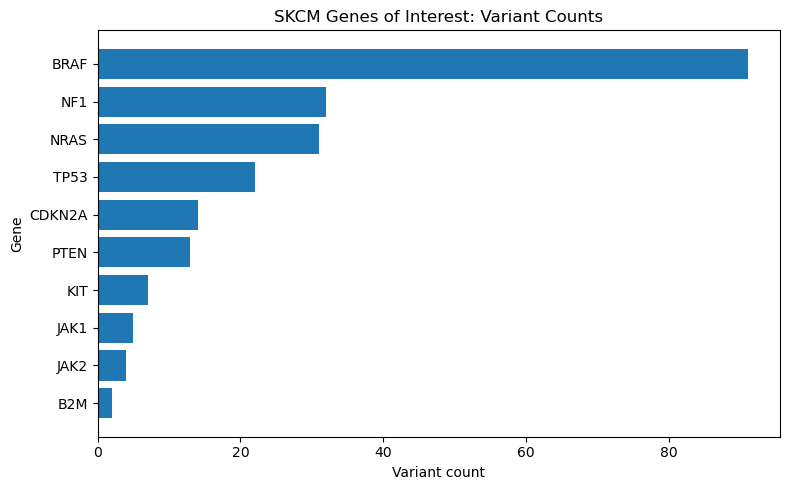

In [26]:
plt.figure(figsize=(8, 5))
plt.barh(skcm_goi_summary["Hugo_Symbol"], skcm_goi_summary["Variant_Count"])
plt.gca().invert_yaxis()
plt.xlabel("Variant count")
plt.ylabel("Gene")
plt.title("SKCM Genes of Interest: Variant Counts")
plt.tight_layout()
plt.show()

## Initial Interpretation

This SKCM analysis combines open-access GDC masked somatic mutation MAF files and summarizes mutation patterns across downloaded aliquot-level files. The first layer of analysis describes mutation classifications, variant types, recurrently altered genes, and mutation counts per sample.

The outlier analysis identifies samples with unusually high mutation counts using an exploratory IQR-based threshold. These samples may be useful for later investigation of hypermutation, tumor mutational burden-style patterns, and immunotherapy-related biomarker concepts.

The genes-of-interest table provides a focused view of variants in melanoma-relevant signaling genes and immune escape-related genes. This helps connect the broader mutation summary to biologically interpretable melanoma and immunotherapy themes.

## Limitations

This analysis is for educational and portfolio purposes only. Mutation counts per sample are used as a simplified exploratory proxy and are not clinically validated TMB values. A clinically reportable TMB calculation would require normalization to a validated assay footprint or callable genomic territory, quality-control thresholds, and laboratory-specific validation.

The genes-of-interest table identifies variants in selected genes but does not perform clinical variant interpretation, therapeutic matching, or evidence tiering.